## 기술면접 코칭 에이전트

---

### 이름

기술면접 코칭 에이전트

---

### 목적

**"지원자가 쓴 자기소개서·포트폴리오와 지원 회사의 채용공고를 교차 분석하여, 그 회사·그 포지션·그 사람에게만 존재하는 맞춤형 기술면접 질문을 생성하고, 세션이 쌓일수록 취약점을 추적해 정교하게 코칭한다."**

- **첫째**, 기존 AI 면접 서비스는 직무 카테고리 기반의 범용 질문을 출제하기 때문에, A회사 지원자와 B회사 지원자가 동일한 질문을 받습니다. InterviewForge는 JD의 우대 사항과 지원자의 실제 경험을 교차 분석해 **세상에 단 하나뿐인 질문**을 생성합니다.

- **둘째**, 단발성 피드백으로 끝나는 기존 서비스와 달리, 세션 이력을 State로 누적하여 **회차가 거듭될수록 취약한 영역에 집중 출제**하는 적응형 코칭을 제공합니다.

- **셋째**, 취업준비생이 혼자서는 발견하기 어려운 **"내 이력서의 리스크 포인트"**, 즉 JD 요건 대비 부족한 역량을 사전에 파악하고 대비할 수 있게 합니다.

---

### 핵심 기능

#### 기능 1. JD × 자소서 × 포트폴리오 3자 교차 분석

입력된 세 가지 문서를 교차 분석하여 구조화된 분석 리포트를 생성합니다.

```
[분석 항목]
├── 기술 매핑    : JD 요구 스킬 vs 보유 스킬 매칭률
├── Gap 분석    : 우대 사항 중 보완이 필요한 역량
├── 강조 포인트  : 면접에서 적극적으로 어필할 경험 추출
└── 리스크 포인트: 면접관이 파고들 가능성이 높은 취약 지점
```

이 분석 결과가 이후 모든 질문 생성의 기반이 됩니다.

#### 기능 2. 3유형 맞춤 질문 생성 + 답변 수준별 동적 분기

분석 결과를 바탕으로 직무 기술 질문, 경험 검증 질문, 압박·꼬리 질문의 세 가지 유형을 자동으로 생성하고, 사용자의 답변 수준에 따라 다음 질문이 동적으로 바뀝니다.

```
[답변 수준 판단]
├── 8점 이상 → 심화 꼬리 질문으로 자동 분기
├── 5~7점   → 보완 포인트 안내 + 유사 난이도 재출제
└── 4점 이하 → 힌트 제공 + 관련 개념 재설명 + 재출제
```

단순히 질문 목록을 순서대로 읽어주는 게 아니라, 대화의 흐름에 따라 실시간으로 질문이 재구성됩니다.

#### 기능 3. 세션 이력 기반 적응형 취약점 추적 코칭

SqliteSaver를 통해 모든 세션의 답변 이력과 평가 점수를 영속적으로 저장하고, 다음 세션에 자동으로 반영합니다.

```
[이력 관리 항목]
├── 세션별 질문 유형 × 점수 매트릭스
├── 취약 카테고리 가중치 (높을수록 다음 세션 출제 비중 증가)
├── 회차별 점수 추이 그래프
└── 세션 종료 시 개선 리포트 자동 생성
```

세션이 쌓일수록 에이전트가 사용자를 더 잘 알게 되어, 3회차 면접은 1회차보다 훨씬 정교한 코칭이 이루어집니다.


### 자율 에이전트 확장 계획

| 구분           | 현재              | 목표                              |
| -------------- | ----------------- | --------------------------------- |
| 분기 결정 주체 | 개발자 (하드코딩) | Claude (상황 판단)                |
| 분기 기준      | score 숫자 하나   | 다차원 컨텍스트                   |
| 외부 정보 수집 | 사용자 입력만     | 웹 검색·GitHub 자율 수집          |
| 자기 검토      | 없음              | 질문 품질 자가 평가 후 재생성     |
| 전략 수립      | 없음              | 지원자별 맞춤 면접 전략 자율 수립 |

#### 확장 A. Reflection — `question_critic` 노드 (1순위)

에이전트가 생성한 질문의 품질을 **스스로 검토하고 기준 미달 시 재생성**합니다.

```
questioner 질문 생성
        │
        ▼
question_critic
  ├── "JD 우대사항 연결 질문 40% 미만" → questioner 재생성 요청 (최대 3회)
  ├── "자소서 경험 검증 질문 없음"     → questioner 재생성 요청
  └── 품질 기준 충족                  → human_review 진행
```

#### 확장 B. Planning — `planner` 노드 (2순위)

에이전트가 분석 결과를 바탕으로 **"이 지원자에게 어떤 면접이 최적인가"를 스스로 판단**합니다.

```
analyzer 결과 수신
        │
        ▼
planner (자율 전략 수립)
  ├── Gap이 큰 경우  → 직무 기술 질문 비중 50%↑
  ├── 우대 충족 높음 → 심화·압박 질문 비중 40%↑
  └── 이전 세션 취약 영역 존재 → 해당 유형 가중 출제
        │
        ▼
interview_strategy → questioner에 전달
```

#### 확장 C. Tool 사용 — `tool_node` + `analyzer` 루프 (3순위)

에이전트가 **스스로 필요하다고 판단할 때 외부 정보를 수집**합니다.

```
[제공할 도구]
├── web_search_tool   : 회사 기술 블로그·면접 후기 검색
├── github_fetch_tool : 포트폴리오 GitHub 코드 직접 분석
└── company_info_tool : 회사 실제 기술 스택 수집

[Claude의 자율 판단 기준]
├── 포트폴리오에 GitHub URL 있음 → github_fetch_tool 호출
├── JD에 회사명 있음             → company_info_tool 호출
├── 최신 기술 키워드 감지        → web_search_tool 호출
└── 모든 정보 충분               → 도구 미호출, 다음 단계 진행
```


In [8]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict

In [9]:
from pathlib import Path

DATA_DIR = Path("data")
ALLOWED_EXTENSIONS = {".txt", ".md", ".pdf"}


def get_files(subdir: str) -> list[str]:
    folder = DATA_DIR / subdir
    if not folder.exists():
        return []
    return [f.name for f in sorted(folder.iterdir()) if f.suffix in ALLOWED_EXTENSIONS]


jd_files = get_files("jd")
resume_files = get_files("resume")
portfolio_files = get_files("portfolio")

print("📂 채용공고 (JD):")
for i, f in enumerate(jd_files, 1):
    print(f"  {i}. {f}")

print("\n📂 자기소개서:")
for i, f in enumerate(resume_files, 1):
    print(f"  {i}. {f}")

print("\n📂 포트폴리오:")
for i, f in enumerate(portfolio_files, 1):
    print(f"  {i}. {f}")

print("\n👇 아래 셀에서 번호를 입력하세요.")

📂 채용공고 (JD):
  1. [소크라에이아이] AI engineer (AI Agent)(신입) 채용 공고 _ 원티드.pdf

📂 자기소개서:

📂 포트폴리오:

👇 아래 셀에서 번호를 입력하세요.


In [10]:
# 위 목록을 보고 번호를 직접 수정하세요 (파일 없으면 None)
JD_IDX = 1
RESUME_IDX = None
PORTFOLIO_IDX = None


def pick(files, idx, subdir):
    if idx is None or not files:
        return None
    return str(DATA_DIR / subdir / files[idx - 1])


selected_files = {
    "jd": pick(jd_files, JD_IDX, "jd"),
    "resume": pick(resume_files, RESUME_IDX, "resume"),
    "portfolio": pick(portfolio_files, PORTFOLIO_IDX, "portfolio"),
}

print("✅ 선택 완료")
for key, path in selected_files.items():
    print(f"  {key}: {path if path else '(없음)'}")

✅ 선택 완료
  jd: data\jd\[소크라에이아이] AI engineer (AI Agent)(신입) 채용 공고 _ 원티드.pdf
  resume: (없음)
  portfolio: (없음)


In [ ]:
from typing import Annotated
from langgraph.graph.message import add_messages


class State(TypedDict):
    # 파일 선택
    selected_files: dict  # {"jd": "경로", "resume": None, "portfolio": None}

    # 입력 원본
    jd_raw: str
    resume_raw: str
    portfolio_raw: str

    # 파싱 결과
    jd_parsed: dict  # {"주요업무": [...], "자격요건": [...], "우대사항": [...]}
    resume_parsed: dict  # {"이름": ..., "기술스택": [...], "프로젝트경험": [...], ...}
    portfolio_parsed: dict  # {"기술스택": [...], "프로젝트": [...], ...}

    # 분석 결과 (analyzer~)
    skill_match: dict
    risk_points: list[str]
    jd_keywords: list[str]
    experience_highlights: list[str]

    # 면접 진행
    question_pool: list[dict]
    current_question: dict
    current_answer: str
    messages: Annotated[list, add_messages]
    current_score: float
    score_history: list[float]
    session_history: list[dict]
    weak_categories: list[str]
    answered_count: int
    total_questions: int
    interview_complete: bool
    retry_flag: bool


graph_builder = StateGraph(State)

In [ ]:
import json
from dotenv import load_dotenv
from langchain_anthropic import ChatAnthropic

from app.parsers.file_parser import read_file, extract_json
from app.prompts.input_parser_prompt import (
    JD_PARSE_PROMPT,
    RESUME_PARSE_PROMPT,
    PORTFOLIO_PARSE_PROMPT,
)

load_dotenv()

llm = ChatAnthropic(model="claude-sonnet-4-6", max_tokens=2048)


def input_parser(state: State) -> dict:
    files = state.get("selected_files", {})

    jd_raw = read_file(files.get("jd"))
    resume_raw = read_file(files.get("resume"))
    portfolio_raw = read_file(files.get("portfolio"))

    jd_parsed = {}
    if jd_raw:
        try:
            response = llm.invoke(JD_PARSE_PROMPT.format(jd_raw=jd_raw))
            jd_parsed = extract_json(response.content)
        except (json.JSONDecodeError, ValueError):
            jd_parsed = {"주요업무": [], "자격요건": [], "우대사항": []}

    resume_parsed = {}
    if resume_raw:
        try:
            response = llm.invoke(RESUME_PARSE_PROMPT.format(resume_raw=resume_raw))
            resume_parsed = extract_json(response.content)
        except (json.JSONDecodeError, ValueError):
            resume_parsed = {}

    portfolio_parsed = {}
    if portfolio_raw:
        try:
            response = llm.invoke(
                PORTFOLIO_PARSE_PROMPT.format(portfolio_raw=portfolio_raw)
            )
            portfolio_parsed = extract_json(response.content)
        except (json.JSONDecodeError, ValueError):
            portfolio_parsed = {}

    print("✅ input_parser 완료")
    print(
        f"  JD       : {len(jd_raw)}자 → {list(jd_parsed.keys()) if jd_parsed else '(없음)'}"
    )
    print(
        f"  자소서    : {len(resume_raw)}자 → {list(resume_parsed.keys()) if resume_parsed else '(없음)'}"
    )
    print(
        f"  포트폴리오: {len(portfolio_raw)}자 → {list(portfolio_parsed.keys()) if portfolio_parsed else '(없음)'}"
    )

    return {
        "jd_raw": jd_raw,
        "resume_raw": resume_raw,
        "portfolio_raw": portfolio_raw,
        "jd_parsed": jd_parsed,
        "resume_parsed": resume_parsed,
        "portfolio_parsed": portfolio_parsed,
    }

In [13]:
from app.prompts.analyzer_prompt import ANALYZER_PROMPT


def analyzer(state: State) -> dict:
    jd_parsed = state.get("jd_parsed", {})
    resume_parsed = state.get("resume_parsed", {})
    portfolio_parsed = state.get("portfolio_parsed", {})

    response = llm.invoke(
        ANALYZER_PROMPT.format(
            jd_parsed=json.dumps(jd_parsed, ensure_ascii=False),
            resume_parsed=json.dumps(resume_parsed, ensure_ascii=False),
            portfolio_parsed=json.dumps(portfolio_parsed, ensure_ascii=False),
        )
    )

    try:
        result = extract_json(response.content)
    except (json.JSONDecodeError, ValueError):
        result = {
            "skill_match": {"matched": [], "missing": []},
            "risk_points": [],
            "jd_keywords": [],
            "experience_highlights": [],
        }

    print("✅ analyzer 완료")
    print(f"  매칭 기술    : {result.get('skill_match', {}).get('matched', [])}")
    print(f"  부족 기술    : {result.get('skill_match', {}).get('missing', [])}")
    print(f"  리스크 포인트: {len(result.get('risk_points', []))}개")
    print(f"  JD 키워드   : {result.get('jd_keywords', [])}")

    return {
        "skill_match": result.get("skill_match", {"matched": [], "missing": []}),
        "risk_points": result.get("risk_points", []),
        "jd_keywords": result.get("jd_keywords", []),
        "experience_highlights": result.get("experience_highlights", []),
    }


def questioner(state):
    print("3유형 질문 Pool 생성")


def human_review(state):
    print("멘토 검토, 질문 승인 (interrupt)")


def interviewer(state):
    print("질문 출제, 답변 수집")


def hint_provider(state):
    print("힌트 + 재출제")


def similar_q(state):
    print("유사 질문 재출제")


def followup_gen(state):
    print("심화 꼬리 질문")


def evaluator(state):
    print("채점, State 업데이트")


def report_gen(state):
    print("평가 리포트, 이력 저장")

In [14]:
# input_parser → analyzer graph 실행 테스트
test_graph = StateGraph(State)
test_graph.add_node("input_parser", input_parser)
test_graph.add_node("analyzer", analyzer)
test_graph.add_edge(START, "input_parser")
test_graph.add_edge("input_parser", "analyzer")
test_graph.add_edge("analyzer", END)

result = test_graph.compile().invoke({"selected_files": selected_files})

print("\n--- skill_match ---")
print(f"  매칭: {result['skill_match']['matched']}")
print(f"  부족: {result['skill_match']['missing']}")

print("\n--- risk_points ---")
for rp in result["risk_points"]:
    print(f"  - {rp}")

print("\n--- experience_highlights ---")
for eh in result["experience_highlights"]:
    print(f"  - {eh}")

✅ input_parser 완료
  JD       : 1921자 → ['주요업무', '자격요건', '우대사항']
  자소서    : 0자 → (없음)
  포트폴리오: 0자 → (없음)
✅ analyzer 완료
  매칭 기술    : []
  부족 기술    : ['LLM 기반 AI Agent 개발', '백엔드 서버 설계·구현·운영', 'RAG(Retrieval-Augmented Generation)', '사용자 메모리·컨텍스트 관리', '자동화된 평가 파이프라인 구축', 'LangGraph 활용 경험', 'LangChain 활용 경험', '멀티 에이전트 구조 설계 및 운영', 'LLM API 서빙 및 운영 최적화', 'TTS 모델 API 서빙 경험', '이미지 생성 모델 API 서빙 경험', '트래픽·지연시간·비용 최적화', 'AI/ML/LLM 기초 지식', '다양한 직군 이해관계자와의 협업 아키텍처 설계', '프론트엔드 개발 경험', '데이터 시스템 개발 경험', 'DevOps 경험', '코드 리뷰 및 피드백 역량']
  리스크 포인트: 7개
  JD 키워드   : ['LLM', 'AI Agent', 'RAG', '멀티 에이전트', 'LangGraph', 'LangChain', '백엔드 서버', '컨텍스트 관리', '사용자 메모리', '평가 파이프라인', '응답 품질 검증', 'TTS', '이미지 생성 모델', 'API 서빙', '트래픽 최적화', '지연시간 최적화', '비용 최적화', '시스템 설계', 'DevOps', '코드 리뷰', '교육 AI', 'Socra AI']

--- skill_match ---
  매칭: []
  부족: ['LLM 기반 AI Agent 개발', '백엔드 서버 설계·구현·운영', 'RAG(Retrieval-Augmented Generation)', '사용자 메모리·컨텍스트 관리', '자동화된 평가 파이프라인 구축', 'LangGraph 활용 경험', 'LangChain 활용 경험', '멀티 에이전트 구조 설계 및 운영', '

In [15]:
# 노드 추가
graph_builder.add_node("input_parser", input_parser)
graph_builder.add_node("analyzer", analyzer)
graph_builder.add_node("questioner", questioner)
graph_builder.add_node("human_review", human_review)

graph_builder.add_node("interviewer", interviewer)
graph_builder.add_node("hint_provider", hint_provider)
graph_builder.add_node("similar_q", similar_q)
graph_builder.add_node("followup_gen", followup_gen)

graph_builder.add_node("evaluator", evaluator)
graph_builder.add_node("report_gen", report_gen)


In [16]:
# 조건 추가
def route_by_score(state):
    score = state["current_score"]

    if score >= 8.0:
        return "followup"
    elif score >= 5.0:
        return "similar"
    else:
        return "hint"


def check_completion(state):
    if state["answered_count"] >= state["total_questions"]:
        return "done"
    return "continue"

In [17]:
# 엣지 추가
graph_builder.add_edge(START, "input_parser")
graph_builder.add_edge("input_parser", "analyzer")
graph_builder.add_edge("analyzer", "questioner")
graph_builder.add_edge("questioner", "human_review")
graph_builder.add_edge("human_review", "interviewer")
graph_builder.add_edge("report_gen", END)

graph_builder.add_edge("hint_provider", "evaluator")
graph_builder.add_edge("similar_q", "evaluator")
graph_builder.add_edge("followup_gen", "evaluator")

graph_builder.add_conditional_edges(
    "interviewer",
    route_by_score,
    {
        "hint": "hint_provider",
        "similar": "similar_q",
        "followup": "followup_gen",
    },
)

graph_builder.add_conditional_edges(
    "evaluator",
    check_completion,
    {
        "done": "report_gen",  # 완료 → 리포트
        "continue": "interviewer",  # 계속 → 면접 루프
    },
)

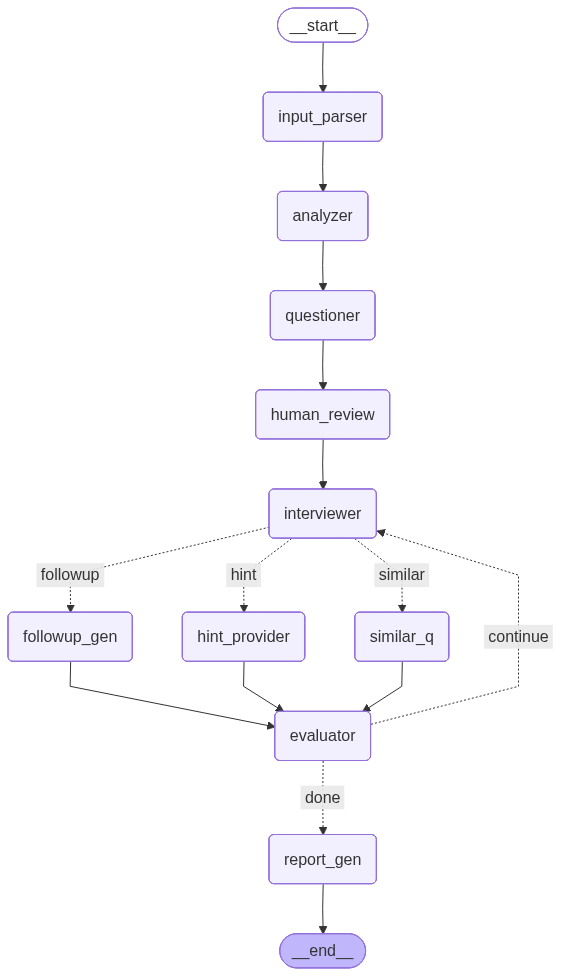

In [18]:
graph = graph_builder.compile()

graph